In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import expm
from itertools import product

In [ ]:
def psi_rhs(t, f, psi, H):
    """
    Return dpsi/dt.

    Parameters:
    t : float
    f : complex ndarray, shape (N,)
        Values f_gamma(t).
    psi : complex ndarray, shape (N, 2, 2)
        psi[gamma, particle, state].
    H : complex ndarray, shape (4, 4)

    Returns
    dpsi : complex ndarray, shape (N, 2, 2)
    """

    dpsi = np.zeros_like(psi, dtype=complex)

    for gamma in range(N): # number of slaters
        for n in range(2): # number of particles
            for v in range(2): # number of single-particle basis states L,R
                
                dpsi[gamma, n, u] = -1j * psi[gamma, n, u]

    return dpsi

# number of Slater determinants
N = 2

a = 1
mu = 4
H = np.array([[a+mu,-a/2,-a/2,0],
              [-a/2,a,0,-a/2],
              [-a/2,0,a,-a/2],
              [0,-a/2,-a/2,a+mu]], dtype=complex)

def pair_index(a,b):
    # to get the index in the 2-particle basis LL LR RL RR
    return 2*a+b

def psi_rhs(t,f,psi,H,singular_tolerance=1e-12):
    """
    Here we define the equations for d_psi/dt, for all gamma, n (particle), and v (state L,R)

    Conventions:
    
    f.shape = (N,)
        f[gamma] = f_gamma(t)

    psi.shape = (N,2,2)
        psi[gamma, 0, 0] = psi_(gamma,1,L)
        psi[gamma, 0, 1] = psi_(gamma,1,R)
        psi[gamma, 1, 0] = psi_(gamma,2,L)
        psi[gamma, 1, 1] = psi_(gamma,2,R)

    H.shape = (4,4)
        Basis LL LR RL RR

    Returns
    d_psi : complex ndarray with shape (N,2,2)
        d_psi[gamma, 0, 0] = d_psi_(gamma,1,L)/dt
    """
    
    # number of slaters
    N = len(f)

    # The equation contains 1/f_gamma.
    if np.any(np.abs(f) < singular_tolerance):
        bad_indices = np.where(np.abs(f) < singular_tolerance)[0]

        raise FloatingPointError(
            "The psi equation is singular because the following "
            f"f_gamma values are close to zero: gamma={bad_indices.tolist()}. "
            "The equation explicitly contains 1/f_gamma."    )

    # Make 2-particle ket for H |psi_beta,1  psi_beta,2 > where 1 and 2 are the particles 
    # in basis LL LR RL RR
    psi12_beta = np.einsum("bk,bl->bkl", psi[:, 0, :], psi[:, 1, :]).reshape(N,4)
    f_psi12_beta = f[:,np.newaxis] * psi12_beta 
    # above, the newaxis allows us to multiply componentwise, so that f_beta for each beta is multiplied by all 4 entries of psi12 for that beta
    f_psi12 = np.sum(f_psi12_beta,axis=0) # sum over beta
    # now apply the Hamiltonian:
    f_H_psi12 = H @ f_psi12


    # Now start making the equations of motion
    d_psi = np.zeros_like(psi, dtype=complex)

    for gamma in range(N): # for the possible Slaters
        for v in range(2): # for 2 states L,R of the particle corresp to psi on LHS of equation
            
            # now we need 2 separate forms depending on if the equation is for the 1st particle or the second particle
            
            # if 1st particle: index=0
            total_n1 = 0.0j
            for j in range(2): # possible L,R of the other particle
                vj_index = pair_index(v,j) # index corresp to LL LR RL RR
                # sum over j:
                total_n1 += ( np.conj(psi[gamma,1,j]) * f_H_psi12[vj_index] )
                # above, psi function is for the other particle, therefore index 1. Term with H is that index because <vj|
            
            # differential equation for first particle wavefunction:
            d_psi[gamma,0,v] = -1j* total_n1 / f[gamma]

            
            # now same but if 2st particle: index=1
            total_n2 = 0.0j
            for j in range(2): # possible L,R of the other particle
                jv_index = pair_index(j,v) # NOW SWAPPED, index corresp to LL LR RL RR
                # sum over j:
                total_n2 += ( np.conj(psi[gamma,0,j]) * f_H_psi12[jv_index] )
                # above, psi function is for the other particle, therefore index 1. Term with H is that index because <vj|
            
            # differential equation for second particle wavefunction:
            d_psi[gamma,1,v] = -1j* total_n2 / f[gamma]
    
    # print('d_psi shape ',d_psi.shape)
    return d_psi


def coupled_rhs(t,y,H,N):
    """
    Now the full coupled set of differential equations

    y contains: [all f (coefficient) values, all flattened psi (wavefunction) values]
    """

    f = y[:N]
    psi = y[N:].reshape(N,2,2)

    d_psi = psi_rhs(t,f,psi,H)

    # Now make the differential equations for the Slater weight functions f
    
    # term containing inner product with H: 
    # Make 2-particle ket for <psi_gamma,1  psi_gamma,2 | H |psi_beta,1  psi_beta,2 > where 1 and 2 are the particles 
    # create psi12[gamma], in basis LL LR RL RR
    psi12 = np.einsum("bk,bl->bkl", psi[:, 0, :], psi[:, 1, :]).reshape(N,4)

    # now an NxN matrix with indices gamma,beta (from the two psi's)
    # (N, 4) @ (4, 4) @ (4, N) -> (N, N)
    V_gamma_beta = psi12.conj() @ H @ psi12.T
    
    # matrix multiply with the f_beta functions to sum over beta
    # shape (N,) so now only depends on gamma:
    interaction = V_gamma_beta @ f


    # term containing derivative of psi
    # A[gamma] = sum_(p,u)  conjugate(psi[gamma,p,u])  d_psi[gamma,p,u]/dt
    A = np.sum( psi.conj() * d_psi, axis=(1,2) )
    # then multiply component-wise with f[gamma], not matrix multiplication, so that preserve gamma index: 
    
    # differential equation for the Slater weightings
    d_f = -1j* interaction - A * f

    # want to return all the differential equations for f and then psi 
    return np.concatenate(( d_f, d_psi.ravel() ))


In [91]:
# initial conditions
f0 = np.array([0.8,0.2])
f0 /= np.linalg.norm(f0)

psi0 = np.zeros((N, 2, 2), dtype=complex)

for particle in range(2):
    psi0[0,particle,:] = np.array([0.8,0.2],dtype=complex)
    psi0[0,particle,:] /= np.linalg.norm(psi0[0,particle,:])
    print(psi0[0,particle,:])
    psi0[1,particle,:] = np.array([0.2,-0.8],dtype=complex)
    psi0[1,particle,:] /= np.linalg.norm(psi0[1,particle,:])
    print(psi0[1,particle,:])

y0 = np.concatenate(( f0, psi0.ravel() ))


"""
Consistency checks for integration

'assert' continues on if answer is True, or raises error if False
""" 
assert H.shape == (4, 4)
assert f0.shape == (N,)
assert psi0.shape == (N, 2, 2)
assert y0.shape == (N + 4 * N,)

# Evaluate the RHS once to catch indexing errors.
test_derivative = coupled_rhs(t=0.0, y=y0, H=H, N=N)
assert test_derivative.shape == y0.shape
assert np.all(np.isfinite(test_derivative))

print("Initial state shape:", y0.shape)
print("Initial derivative shape:", test_derivative.shape)


[0.9701425 +0.j 0.24253563+0.j]
[ 0.24253563+0.j -0.9701425 +0.j]
[0.9701425 +0.j 0.24253563+0.j]
[ 0.24253563+0.j -0.9701425 +0.j]
Initial state shape: (10,)
Initial derivative shape: (10,)


f_solution shape: (2, 501)
psi_solution shape: (2, 2, 2, 501)


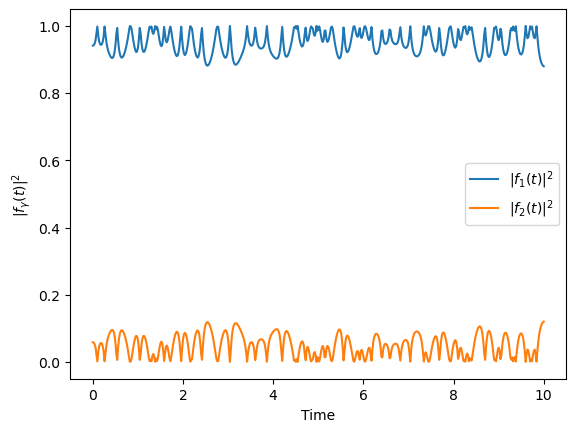

In [92]:
# Numerical integration

t_list = np.linspace(0.0,10.0,501)
solution = solve_ivp( 
    fun=lambda t, y: coupled_rhs(t,y,H,N),
    t_span = (t_list[0],t_list[-1]), 
    y0 = y0,
    t_eval = t_list,
    method = "DOP853", # got same result with BDF for a calculation
    rtol=1e-9,
    atol=1e-11,
)

if not solution.success:
    raise RuntimeError(
        f"Integration failed: {solution.message}"
    )

f_solution = solution.y[:N, :]
psi_solution = solution.y[N:,:].reshape(N,2,2,len(solution.t))
print("f_solution shape:", f_solution.shape)
print("psi_solution shape:", psi_solution.shape)

f_gamma0 = f_solution[0, :]
psi_gamma0_particle1_L = psi_solution[0, 0, 0, :]
psi_gamma0_particle1_R = psi_solution[0, 0, 1, :]
psi_gamma0_particle2_L = psi_solution[0, 1, 0, :]
psi_gamma0_particle2_R = psi_solution[0, 1, 1, :]

for gamma in range(N):
    plt.plot(
        solution.t,
        np.abs(f_solution[gamma, :])**2,
        label=fr"$|f_{{{gamma+1}}}(t)|^2$" )
plt.xlabel("Time")
plt.ylabel(r"$|f_\gamma(t)|^2$")
plt.legend()
plt.show()

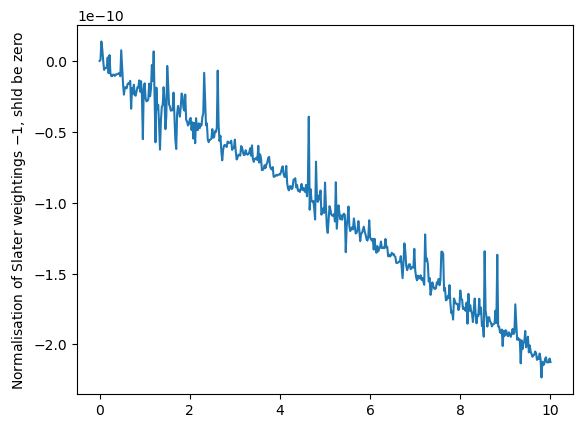

In [93]:
plt.plot(solution.t,np.abs(f_solution[0, :])**2+np.abs(f_solution[1, :])**2-1)
plt.ylabel(r'Normalisation of Slater weightings $- 1$, shld be zero')
plt.show()

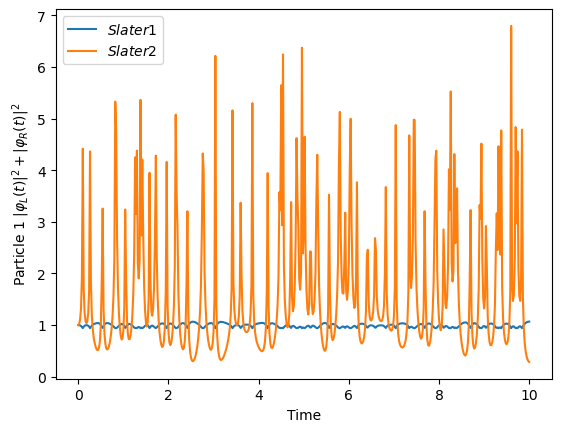

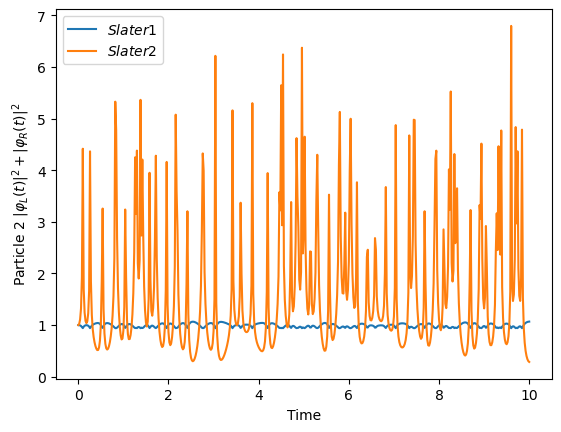

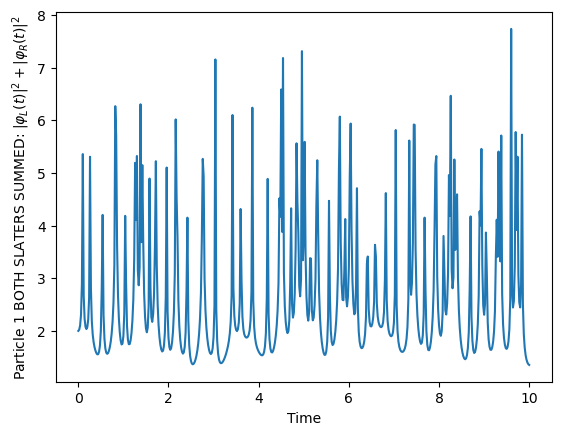

In [94]:
for gamma in range(N):
    plt.plot(
        solution.t,
        np.abs(psi_solution[gamma, 0, 0, :])**2 + np.abs(psi_solution[gamma, 0, 1, :])**2,
        label=fr"$Slater {gamma+1}$")
plt.xlabel("Time")
plt.ylabel(r"Particle 1 $|\varphi_L(t)|^2+|\varphi_R(t)|^2$")
# plt.ylim(0,1)
plt.legend()
plt.show()

for gamma in range(N):
    plt.plot(
        solution.t,
        np.abs(psi_solution[gamma, 1, 0, :])**2 + np.abs(psi_solution[gamma, 1, 1, :])**2,
        label=fr"$Slater {gamma+1}$")
plt.xlabel("Time")
plt.ylabel(r"Particle 2 $|\varphi_L(t)|^2+|\varphi_R(t)|^2$")
# plt.ylim(0,1)
plt.legend()
plt.show()


plt.plot(
    solution.t,
    (np.abs(psi_solution[0, 0, 0, :])**2 + np.abs(psi_solution[0, 0, 1, :])**2 + np.abs(psi_solution[1, 0, 0, :])**2 + np.abs(psi_solution[1, 0, 1, :])**2),
    # label=fr"$Slater {gamma+1}$"
)
plt.xlabel("Time")
plt.ylabel(r"Particle 1 BOTH SLATERS SUMMED: $|\varphi_L(t)|^2+|\varphi_R(t)|^2$")
# plt.ylim(0,1)
# plt.legend()
plt.show()

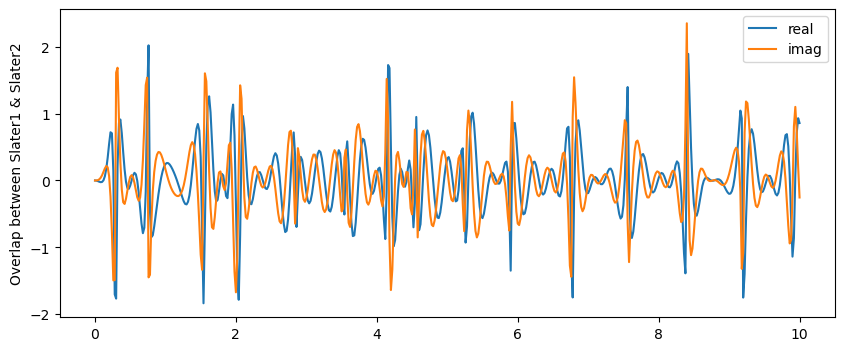

0.013484721944987644 0.0027814702645967346


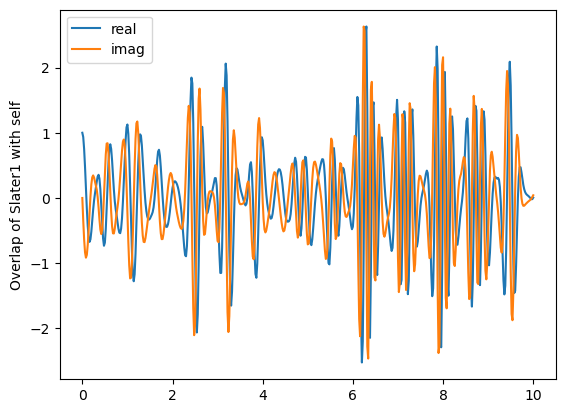

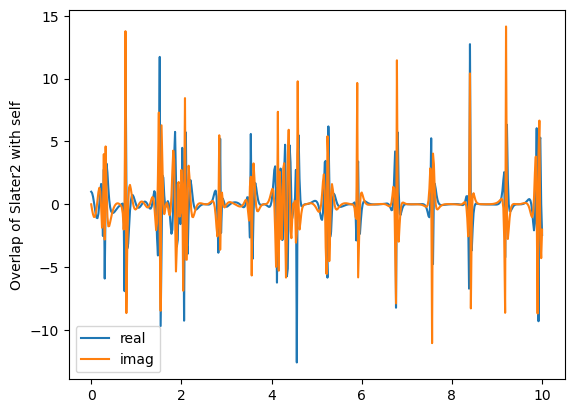

In [83]:
"""
Check inner product between slaters
They start orthogonal so hope they stay so.
Sadly not so far. 
"""
# psi[gamma,particle,state,t]

LL1 = psi_solution[0, 0, 0, :]*psi_solution[0, 1, 0, :]
LR1 = psi_solution[0, 0, 0, :]*psi_solution[0, 1, 1, :]
RL1 = psi_solution[0, 0, 1, :]*psi_solution[0, 1, 0, :]
RR1 = psi_solution[0, 0, 1, :]*psi_solution[0, 1, 1, :]

LL2 = psi_solution[1, 0, 0, :]*psi_solution[1, 1, 0, :]
LR2 = psi_solution[1, 0, 0, :]*psi_solution[1, 1, 1, :]
RL2 = psi_solution[1, 0, 1, :]*psi_solution[1, 1, 0, :]
RR2 = psi_solution[1, 0, 1, :]*psi_solution[1, 1, 1, :]

overlap12 = LL1*LL2 + LR1*LR2 + RL1*RL2 + RR1*RR2
plt.figure(figsize=(10,4))
plt.plot(solution.t,overlap12.real,label='real')
plt.plot(solution.t,overlap12.imag,label='imag')
plt.legend()
plt.ylabel('Overlap between Slater1 & Slater2')
plt.show()
print(np.mean(overlap12.real),np.mean(overlap12.imag))
# See that the two Slaters do not stay orthogonal, inner product is not zero
# averages to close to zero

overlap1 = LL1*LL1 + LR1*LR1 + RL1*RL1 + RR1*RR1
overlap2 = LL2*LL2 + LR2*LR2 + RL2*RL2 + RR2*RR2
plt.plot(solution.t,overlap1.real,label='real')
plt.plot(solution.t,overlap1.imag,label='imag')
plt.ylabel('Overlap of Slater1 with self')
plt.legend()
plt.show()
plt.plot(solution.t,overlap2.real,label='real')
plt.plot(solution.t,overlap2.imag,label='imag')
plt.ylabel('Overlap of Slater2 with self')
plt.legend()
plt.show()

(4, 501)
(501,) (501,)


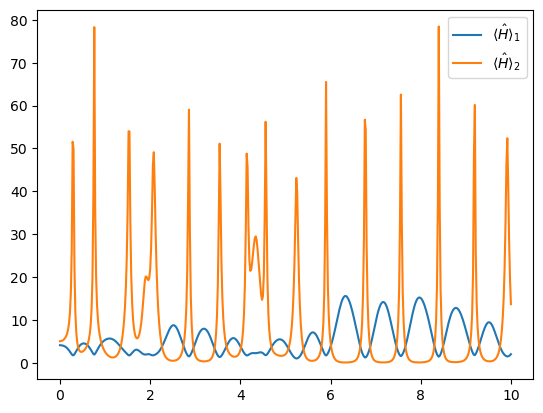

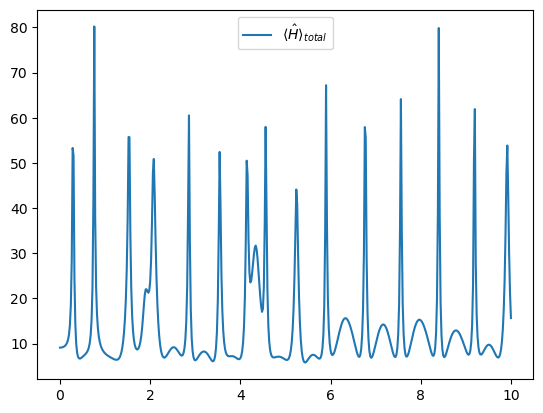

In [84]:
"""
Now check Energy conservation within each Slater, and also in total
"""
slater1 = np.array([LL1,LR1,RL1,RR1],dtype=complex)
slater2 = np.array([LL2,LR2,RL2,RR2],dtype=complex)
print(slater1.shape)

exE_1=[]
exE_2=[]
for t in range(len(solution.t)):
    exE_1_t = slater1[:,t].T.conj() @ H @ slater1[:,t]
    exE_1.append(exE_1_t)
    exE_2_t = slater2[:,t].T.conj() @ H @ slater2[:,t]
    exE_2.append(exE_2_t)
exE_1=np.array(exE_1,dtype=complex)
exE_2=np.array(exE_2,dtype=complex)
print(exE_1.shape,exE_2.shape)

plt.plot(solution.t,exE_1,label=r"$\langle \hat{H} \rangle_1$")
plt.plot(solution.t,exE_2,label=r"$\langle \hat{H} \rangle_2$")
plt.legend()
plt.show()

plt.plot(solution.t,exE_2+exE_1,label=r"$\langle \hat{H} \rangle_{total}$")
plt.legend()
plt.show()

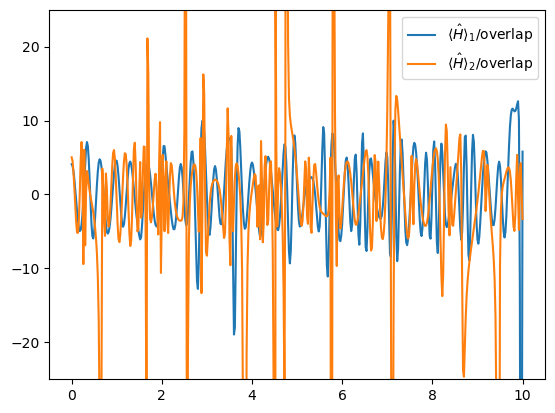

In [87]:
"""
Energy conservation divided by overlap, like in TDGCM paper
Still bad
"""

exEoverlap_1=[]
exEoverlap_2=[]
for t in range(len(solution.t)):
    exEoverlap_1_t = slater1[:,t].T.conj() @ H @ slater1[:,t]/ overlap1[t]
    exEoverlap_1.append(exEoverlap_1_t)
    exEoverlap_2_t = slater2[:,t].T.conj() @ H @ slater2[:,t]/ overlap2[t]
    exEoverlap_2.append(exEoverlap_2_t)
exEoverlap_1=np.array(exEoverlap_1,dtype=complex)
exEoverlap_2=np.array(exEoverlap_2,dtype=complex)

plt.plot(solution.t,exEoverlap_1,label=r"$\langle \hat{H} \rangle_1$/overlap")
plt.plot(solution.t,exEoverlap_2,label=r"$\langle \hat{H} \rangle_2$/overlap")
plt.ylim(-25,25)
plt.legend()
plt.show()